In [58]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## Load Dataset

The Breast Cancer dataset contains medical features used to classify tumors as malignant or benign.

In [59]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:")
print(data.feature_names)

Feature shape: (569, 30)
Target shape: (569,)
Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [60]:
print(data.target_names)
print(y[:10])

['malignant' 'benign']
[0 0 0 0 0 0 0 0 0 0]


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (455, 30)
Testing samples: (114, 30)


In [62]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train.shape)
print(y_train.shape)

torch.Size([455, 30])
torch.Size([455, 1])


## Neural Network Architecture

30 Input Features
        ↓
Hidden Layer: 16 Neurons
        ↓
ReLU
        ↓
Hidden Layer: 8 Neurons
        ↓
ReLU
        ↓
Output Layer: 1 Neuron
        ↓
Binary Classification

In [64]:
class FeedForwardNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(30, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

In [65]:
model = FeedForwardNN()

print(model)

FeedForwardNN(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [66]:
criterion = nn.BCEWithLogitsLoss()

In [67]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [68]:
epochs = 100
losses = []

for epoch in range(epochs):

    # Forward pass
    outputs = model(X_train)

    # Calculate loss
    loss = criterion(outputs, y_train)

    # Store loss
    losses.append(loss.item())

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [10/100], Loss: 0.7057
Epoch [20/100], Loss: 0.6827
Epoch [30/100], Loss: 0.6561
Epoch [40/100], Loss: 0.6209
Epoch [50/100], Loss: 0.5741
Epoch [60/100], Loss: 0.5142
Epoch [70/100], Loss: 0.4439
Epoch [80/100], Loss: 0.3701
Epoch [90/100], Loss: 0.3024
Epoch [100/100], Loss: 0.2465


In [69]:
model.eval()

with torch.no_grad():

    outputs = model(X_test)

    probabilities = torch.sigmoid(outputs)

    predictions = (probabilities >= 0.5).float()

accuracy = accuracy_score(
    y_test.numpy(),
    predictions.numpy()
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 93.86%


In [70]:
print("Predictions:")
print(predictions[:10].view(-1))

print("\nActual:")
print(y_test[:10].view(-1))

Predictions:
tensor([0., 1., 0., 1., 0., 1., 1., 0., 0., 0.])

Actual:
tensor([0., 1., 0., 1., 0., 1., 1., 0., 0., 0.])


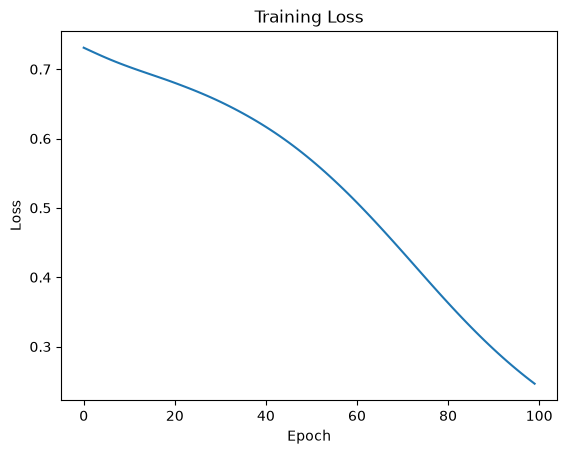

In [71]:
import matplotlib.pyplot as plt

plt.plot(losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

## Training Process

The neural network was trained using the following process:

1. Input features were passed through the neural network.
2. The model produced output values.
3. Binary Cross Entropy loss measured the prediction error.
4. Backpropagation calculated gradients using Autograd.
5. Adam optimizer updated the model weights.
6. This process was repeated for 100 epochs.
7. The trained model was evaluated using unseen test data.

# Day 25 Summary

Today I built and trained a Feedforward Neural Network using PyTorch.

I learned:

- How to prepare data for PyTorch
- Train/test splitting
- Feature normalization
- Converting NumPy arrays to tensors
- Building a Feedforward Neural Network
- Creating multiple hidden layers
- Using ReLU activation
- Using BCEWithLogitsLoss for binary classification
- Using Adam optimizer
- Forward propagation
- Backpropagation
- Model evaluation
- Calculating test accuracy